In [1]:
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp

jax.devices()

[cuda(id=0), cuda(id=1), cuda(id=2), cuda(id=3)]

In [2]:
from probjax.nn.unets import UNet2D

In [3]:
# High dimensional  

from probjax.utils.torchvision_datasets import NumpyLoader, MNIST
j = 0
def transform_data(x):
    # Uniformly quantize
    x = jnp.reshape(jnp.asarray(x, dtype=jnp.float32), (-1, 784))
    normed = x / 255
    global j 
    j += 1 
    normed = normed + jax.random.uniform(jax.random.PRNGKey(j), normed.shape, minval=0, maxval=1/256)
    return normed

mnist_dataset = MNIST('/tmp/mnist/', download=True, transform=transform_data)
training_generator = NumpyLoader(mnist_dataset, batch_size=32, num_workers=0)

input_dim = 784

2023-10-19 20:26:58.726603: W external/xla/xla/service/gpu/nvptx_compiler.cc:703] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


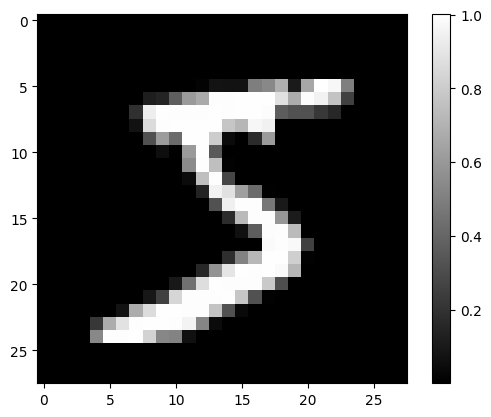

In [4]:
for x, y in training_generator:
    plt.imshow(x[0].reshape(28, 28), cmap='gray')
    plt.colorbar()
    break

In [5]:
from probjax.utils.odeint import _odeint as odeint
from probjax.nn.helpers import TimeEmbedding
from functools import partial

from probjax.nn.unets import SinusoidalEmbedding


def net(t, x):
    m = UNet2D(out_channels=(16, 32, 64), with_attention=True, num_groups=8)
    x = jnp.array(x).reshape(-1, 28, 28, 1)
    t = jnp.array(t).reshape(-1, 1)
    t = SinusoidalEmbedding(32)(t)
    out =  m(x, t)
    out = out.reshape(out.shape[0], -1)
    return out
    
init, forward = hk.without_apply_rng(hk.transform(net))
params = init(jax.random.PRNGKey(0), jnp.ones(1), jnp.ones((784,)))

ts = jnp.linspace(0, 1, 200)

def drift(t, x, params):
    return forward(params, t, x)


(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)


In [6]:
T = 1.
T_min = 1e-5
beta_min = 0.1
beta_max = 15.

def beta(t):
    return beta_min + t * (beta_max - beta_min)

def drift_fn(x, t):
    return -0.5 * (beta(t)) * x

def diffusion_fn(x, t):
    # This migh requrire a square root
    return jnp.sqrt(beta(t)) * jnp.ones_like(x)

def marginal_mean(x0, t):
    phi = jnp.exp(-0.25 * t**2 * (beta_max - beta_min) - 0.5*t * beta_min)
    return phi * x0

def marginal_std(x0, t):
    phi = jnp.exp(-0.5 * t**2 * (beta_max - beta_min) - t * beta_min)
    return jnp.sqrt(1 - 1 * phi)

def sbd_forward(key, x0, t):
    noise = jax.random.normal(key, x0.shape)
    std = marginal_std(x0, t)
    x_noised = marginal_mean(x0, t) + std * noise
    return x_noised

log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
score_fn = jax.grad(log_prob_fn)

In [7]:
# T = 1.
# T_min = 1e-5

# sigma = 5.


# def drift_fn(x, t):
#     return jnp.zeros_like(x)

# def diffusion_fn(x, t):
#     # This migh requrire a square root
#     return sigma ** t * jnp.ones_like(x)

# def marginal_mean(x0, t):
    
#     return x0

# def marginal_std(x0, t):
#     return jnp.sqrt((sigma**(2 * t) - 1.) / 2. / jnp.log(sigma)) * jnp.ones_like(x0)

# def sbd_forward(key, x0, t):
#     noise = jax.random.normal(key, x0.shape)
#     std = marginal_std(x0, t)
#     x_noised = marginal_mean(x0, t) + std * noise
#     return x_noised

# log_prob_fn = lambda x, t, x0: jax.scipy.stats.norm.logpdf(x, marginal_mean(x0, t), marginal_std(x0, t)).sum()
# score_fn = jax.grad(log_prob_fn)

In [8]:
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)


@jax.jit
def loss_fn(params, key, batch_xs):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data
    batch_size = batch_xs.shape[0]
    times = jax.random.uniform(rng_time, (batch_size, 1), minval=T_min, maxval=1.0)

    # Forward diffusion
    batch_noisy_xs = sbd_forward(rng_sample, batch_xs, times)
  
    score_pred = forward(params, times, batch_noisy_xs)
    score_target = score_fn(batch_noisy_xs, times, batch_xs)
    # Weighting function
    # Seems to be important here
    # lam = 1.
    lam = 1-jnp.exp(-0.5 * (beta_max - beta_min) * times**2 - beta_min * times)
    # Loss

    loss = jnp.mean(jnp.sum(lam*(score_pred - score_target) ** 2, axis=-2))
    return loss



In [9]:
@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, rng, batch_xs):

    loss, grads = jax.value_and_grad(loss_fn)(params, rng, batch_xs)
    
    grads = jax.lax.pmean(grads, axis_name='num_devices')
    loss = jax.lax.pmean(loss, axis_name='num_devices')
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state,loss

In [10]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)

In [11]:
n_devices = jax.local_device_count()
replicated_params = jax.tree_map(lambda x: jnp.array([x] * n_devices), params)
replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * n_devices), opt_state)

In [19]:
key = jax.random.PRNGKey(0)
for i in range(5):
    k = 0
    l = 0
    for xs_batch, _ in training_generator:
        key, subkey = jax.random.split(key)
        xs_batch =  jnp.squeeze(xs_batch)
        xs_batch = jnp.reshape(xs_batch, (jax.device_count(), -1, 784))
        subkey = jax.random.split(subkey, (jax.local_device_count(),  ))
        replicated_params, replicated_opt_state, loss = update(replicated_params, replicated_opt_state, subkey,xs_batch)

        k += 1
        l += loss[0]
        
    print(l/k)

0.1656577
0.1606022
0.1595594


2023-10-19 20:45:18.479290: W external/xla/xla/service/gpu/runtime/support.cc:58] Intercepted XLA runtime error:
INTERNAL: the requested functionality is not supported
2023-10-19 20:45:18.479432: W external/xla/xla/service/gpu/runtime/support.cc:58] Intercepted XLA runtime error:
INTERNAL: CaptureGpuGraph failed (the requested functionality is not supported; current tracing scope: custom-call.246): INTERNAL: Failed to end stream capture: CUDA_ERROR_STREAM_CAPTURE_INVALIDATED: operation failed due to a previous error during capture
2023-10-19 20:45:18.480138: E external/xla/xla/pjrt/pjrt_stream_executor_client.cc:2717] Execution of replica 0 failed: INTERNAL: Failed to execute XLA Runtime executable: run time error: custom call 'xla.gpu.graph.launch' failed: CaptureGpuGraph failed (the requested functionality is not supported; current tracing scope: custom-call.246): INTERNAL: Failed to end stream capture: CUDA_ERROR_STREAM_CAPTURE_INVALIDATED: operation failed due to a previous error d

: 

In [13]:
from functools import partial
from probjax.utils.sdeint import sdeint


def drift_backward(t, x):
    #t = T - t
    score = forward(params, t,x)

    f =  drift_fn(x, t) - diffusion_fn(x, t)**2 * score
    f = f.reshape(x.shape)
    return f

def diffusion_backward(t,x):
    #t = T - t
    b =  diffusion_fn(x, t)
    b = b.reshape(x.shape)
    return b

In [14]:
params = jax.tree_map(lambda x: x[0], replicated_params)


def sample_fn(key, shape, time_steps=5000):
    key1, key2 = jax.random.split(key, 2)
    x_T = jax.random.normal(key1, shape + (784,)) * marginal_std(jnp.zeros(shape + (784,)), 1.)
    keys = jax.random.split(key2, shape)
    ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal"), in_axes= (0, None, None, 0, None), out_axes=0)(keys, lambda t, x: drift_backward(t, x), lambda t, x: diffusion_backward(t, x), x_T, jnp.linspace(1.,T_min, time_steps))
    return ys[:, -1, :]

In [17]:
samples = sample_fn(jax.random.PRNGKey(1), (1,))

(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)
(1, 28, 28, 16)
(1, 14, 14, 32)
(1, 7, 7, 64)


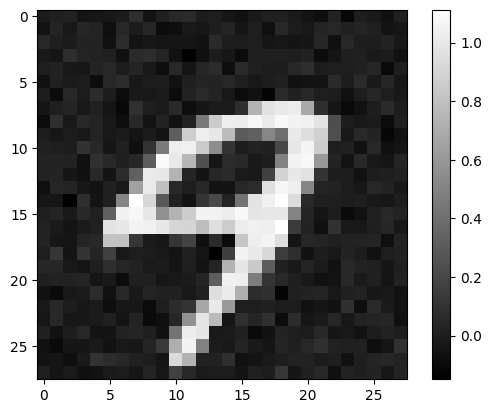

In [18]:
plt.imshow(samples[0].reshape(28, 28), cmap='gray')
plt.colorbar()

In [429]:
plt.imshow(samples[0].reshape(28, 28), cmap='Greys_r')

TypeError: reshape total size must be unchanged, got new_sizes (28, 28) for shape (500, 784).

In [381]:
sigma_min = 1e-1

# Train as if it would be a diffusion process
def loss_fn(params, key, x1):
    """ Optimal transport flow-matching loss.
    """
    key1, key2 = jax.random.split(key, 2)
    t = jax.random.uniform(key1, (x1.shape[0], 1))
    x0 = jax.random.normal(key2, x1.shape)

    # One possibility
    # Optimal transport paths
    # xt = (1 - (1-sigma_min) * t) * x0  + t*x1
    # u = x1 - (1-sigma_min) * x0

    # Diffusion paths
    # beta_min = 0.1 
    # beta_max = 10.
    # alpha_t = jnp.exp(-0.5 * (t*beta_min + 0.5 t**2 * (beta_max - beta_min)))
    # xt = alpha_t * x1 + jnp.sqrt(1- alpha_t**2) * x0
    # u = 

    v_t = jax.vmap(drift, in_axes=(0,0, None))(t, xt, params)
    return jnp.mean(jnp.sum(jnp.square(v_t - u), -1))


    
@jax.jit
def step(params, opt_state, key, x):
    loss, g = jax.value_and_grad(loss_fn)(params, key,x)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss


In [382]:
optimizer = adam(5e-4)
opt_state = optimizer.init(params)

In [387]:
key = jax.random.PRNGKey(0)
for i in range(10):
    k = 0
    l = 0
    for xs_batch, _ in training_generator:
        key, subkey = jax.random.split(key)
        params, opt_state, loss = step(params, opt_state, subkey, jnp.squeeze(xs_batch))
        if k > 500:
            break  
        k += 1
        l += loss / 500

    print(l)

692.80023


KeyboardInterrupt: 

In [388]:
def sample(params, key, shape):
    z0 = jax.random.normal(key, shape + (784,))
    def f(x0):
        return odeint(lambda t, x: drift(t, x, params), x0, jnp.linspace(0,1, 3000), method="bosh3")[-1]
    z1 = jax.vmap(f)(z0)
    return z1

In [391]:
samples = sample(params, jax.random.PRNGKey(1), (1,))

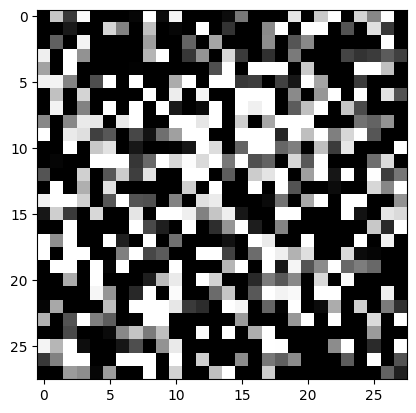

In [392]:
plt.imshow(samples.reshape(28, 28),  cmap="Greys_r", vmin=0, vmax=1)